# Spectrogram Analysis

This notebook computes and visualizes a spectrogram from an audio file using SciPy.


In [1]:
import scipy.signal
import numpy as np
import matplotlib.pyplot as plt
import wave # ספרייה מובנית לטעינת קובצי WAV


## 1. טעינת האודיו (באמצעות ספריית wave)


In [2]:
# נניח שוב קובץ my_audio.wav
with wave.open(r"Z:\Shared\Tamar\PHD project\recordings\R2_17112025.wav", 'rb') as w:
    sr = w.getframerate() # קצב דגימה
    frames = w.readframes(w.getnframes())
    y = np.frombuffer(frames, dtype=np.int16) # גל הקול (בפורמט מספר שלם 16-bit)

# המרה ל-float כדי להתאים ל-DSP

y = y.astype(np.float64) / (2**15)


## 1.5. סינון Bandpass (700-5000 Hz)


In [ ]:
# עיצוב מסנן Butterworth bandpass
lowcut = 30000  # Hz
highcut = 110000  # Hz
order = 5  # סדר המסנן

# חישוב מקדמי המסנן
sos = scipy.signal.butter(order, [lowcut, highcut], btype='band', fs=sr, output='sos')

# החלת המסנן על האותות
y_filtered = scipy.signal.sosfilt(sos, y)

print(f"Bandpass filter applied: {lowcut}-{highcut} Hz")


Bandpass filter applied: 30000-110000 Hz


## 2. חישוב הספקטרוגרמה באמצעות SciPy

- f: מערך התדרים
- t: מערך הזמנים
- Sxx: הספקטרוגרמה (צפיפות הספק)


In [4]:
f, t, Sxx = scipy.signal.spectrogram(y_filtered, 
                                     fs=sr, 
                                     nperseg=1024,
                                     noverlap=512) 


## 3. הצגת ספקטרוגרמה סטטית (חלון של דקה אחת)


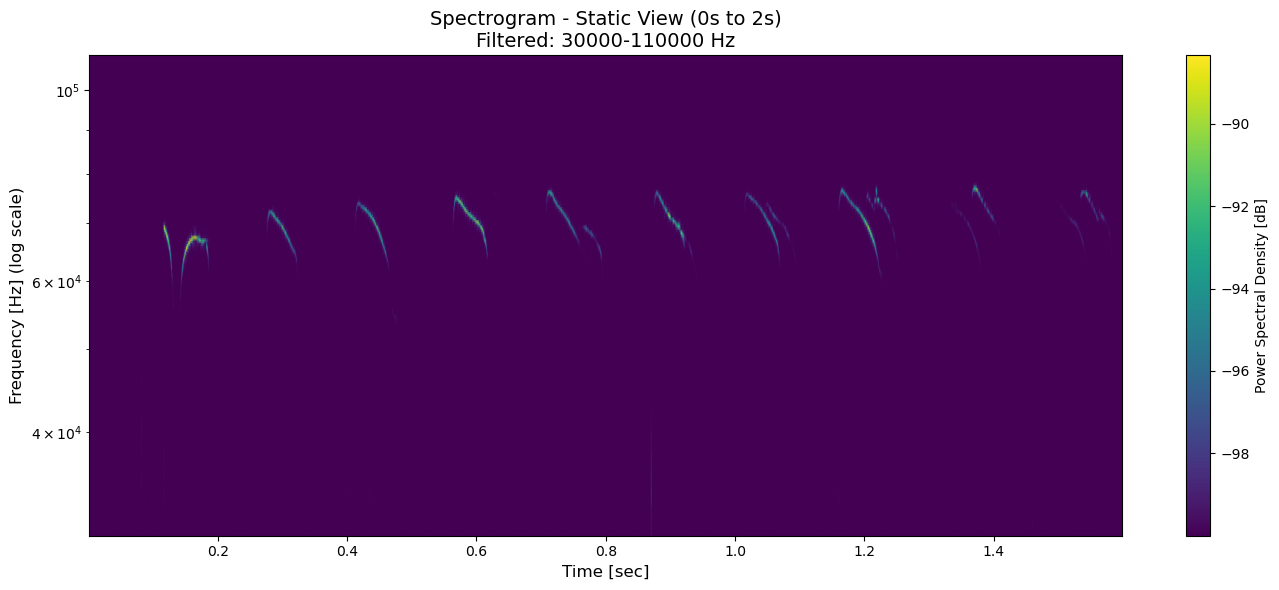

Displayed 2-second window starting at 0s


In [5]:
# הגדרות חלון זמן
static_window_start = 0  # התחלה בשנייה 0
static_window_duration = 2  # משך החלון - דקה אחת

# בחירת הזמנים המתאימים
time_mask_static = (t >= static_window_start) & (t <= (static_window_start + static_window_duration))

# סינון התדרים בטווח המסנן בלבד
freq_mask = (f >= lowcut) & (f <= highcut)

# המרת הספקטרוגרמה ל-dB עם סינון תדרים
Sxx_db_static = 10 * np.log10(Sxx[freq_mask, :][:, time_mask_static] + 1e-10)

# יצירת התמונה הסטטית
plt.figure(figsize=(14, 6))

plt.pcolormesh(t[time_mask_static], f[freq_mask], Sxx_db_static, 
               shading='gouraud', cmap='viridis')

plt.yscale('log')
plt.ylabel('Frequency [Hz] (log scale)', fontsize=12)
plt.xlabel('Time [sec]', fontsize=12)
plt.title(f'Spectrogram - Static View ({static_window_start}s to {static_window_start + static_window_duration}s)\nFiltered: {lowcut}-{highcut} Hz', 
          fontsize=14)
plt.colorbar(label='Power Spectral Density [dB]')

plt.tight_layout()
plt.show()

print(f"Displayed {static_window_duration}-second window starting at {static_window_start}s")


## 4. יצירת סרטון ספקטרוגרמה מתקדמת (15 FPS)


In [6]:
from matplotlib.animation import FuncAnimation, FFMpegWriter

# הגדרות סרטון - מותאם למהירות
fps = 10  # הפחתה ל-10 FPS (במקום 15) למהירות רבה יותר
max_duration = 2  # הגבלת משך הסרטון

# חישוב מספר הפריימים
total_duration = min(t[-1], max_duration)  # משך הקובץ או דקה, הקצר מביניהם
num_frames = int(total_duration * fps)

print(f"Creating animation with {num_frames} frames at {fps} FPS")
print(f"Total duration: {total_duration:.2f} seconds")
print(f"(Full audio duration: {t[-1]:.2f} seconds)")
print(f"Estimated render time: {num_frames * 0.2:.1f}-{num_frames * 0.4:.1f} seconds")


Creating animation with 15 frames at 10 FPS
Total duration: 1.60 seconds
(Full audio duration: 1.60 seconds)
Estimated render time: 3.0-6.0 seconds


Setting up animation with 1-second sliding window and log scale...


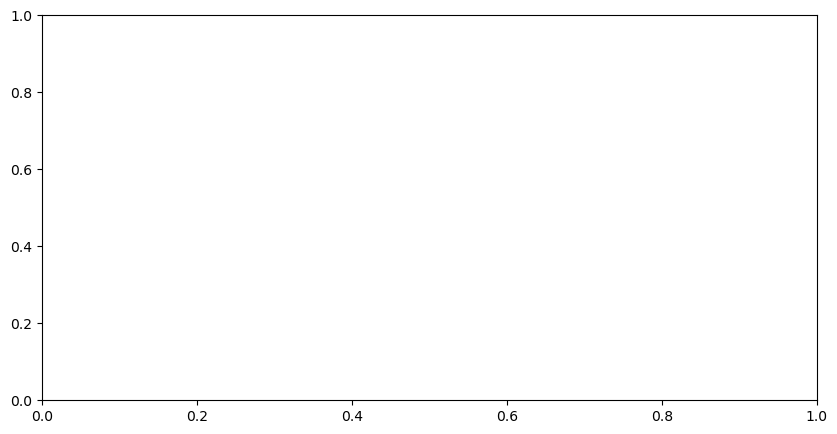

In [7]:
# סינון התדרים בטווח המסנן בלבד
freq_mask = (f >= lowcut) & (f <= highcut)
f_filtered = f[freq_mask]

# המרת הספקטרוגרמה ל-dB עם סינון תדרים
Sxx_filtered = Sxx[freq_mask, :]
Sxx_db = 10 * np.log10(Sxx_filtered + 1e-10)  # הוספת epsilon למניעת log(0)

# הגדרת טווח קבוע לצבעים
vmin = -100  # dB
vmax = -85   # dB

# יצירת figure ו-axis - גודל קטן יותר למהירות
fig, ax = plt.subplots(figsize=(10, 5))

# הגדרות חלון נע
window_duration = 1.0  # חלון של שנייה אחת

def update_frame(frame_num):
    """עדכון כל פריים בסרטון - חלון נע של 1 שנייה"""
    ax.clear()
    
    # זמן נוכחי
    current_time = frame_num / fps
    
    # הגדרת חלון הזמן הנע (1 שנייה)
    time_start = max(0, current_time - window_duration)
    time_end = current_time
    
    # מציאת האינדקסים המתאימים לחלון הזמן
    time_mask = (t >= time_start) & (t <= time_end)
    
    if np.sum(time_mask) > 0:
        # הצגת הספקטרוגרמה בחלון הנע (רק התדרים המסוננים)
        # shading='nearest' מהיר יותר מ-'gouraud'
        ax.pcolormesh(t[time_mask], f_filtered, Sxx_db[:, time_mask], 
                     shading='nearest', cmap='viridis', rasterized=True,
                     vmin=vmin, vmax=vmax)
    
    # הגדרות גרף
    ax.set_xlim(time_start, time_end)  # חלון נע
    ax.set_ylim(lowcut, highcut)
    ax.set_yscale('log')  # סקאלה לוגריתמית
    ax.set_ylabel('Frequency [Hz] (log scale)', fontsize=11)
    ax.set_xlabel('Time [sec]', fontsize=11)
    ax.set_title(f'Spectrogram - Time: {current_time:.2f}s / {total_duration:.2f}s\nFiltered: {lowcut}-{highcut} Hz', 
                fontsize=11)
    
    # קו אדום המציין את הזמן הנוכחי
    ax.axvline(x=current_time, color='red', linestyle='--', linewidth=2, alpha=0.7)
    
    # Progress indicator
    if frame_num % 50 == 0:
        print(f"Progress: {frame_num}/{num_frames} frames ({100*frame_num/num_frames:.1f}%)")
    
    return ax,

print("Setting up animation with 1-second sliding window and log scale...")


In [8]:
# בדיקת כותבי וידאו זמינים
from matplotlib.animation import writers
available_writers = writers.list()
print(f"Available writers: {available_writers}")

# יצירת האנימציה
anim = FuncAnimation(fig, update_frame, frames=num_frames, 
                    interval=1000/fps, blit=False, repeat=False)

# שמירת הסרטון
output_filename = 'spectrogram_movie.mp4'

try:
    # ניסיון ראשון: FFMpeg - DPI נמוך יותר = מהיר יותר
    writer = FFMpegWriter(fps=fps, bitrate=2000, codec='libx264', 
                         extra_args=['-preset', 'ultrafast'])
    print(f"Saving animation to {output_filename} using FFMpeg...")
    print("This may take a few minutes...")
    anim.save(output_filename, writer=writer, dpi=75)  # הפחתת DPI ל-75
    print(f"✅ Animation saved successfully to {output_filename}")
except Exception as e:
    print(f"FFMpeg failed: {e}")
    print("Trying alternative format (GIF)...")
    
    # ניסיון שני: Pillow (GIF)
    output_filename = 'spectrogram_movie.gif'
    print(f"Saving animation to {output_filename} using Pillow...")
    anim.save(output_filename, writer='pillow', fps=fps, dpi=60)
    print(f"✅ Animation saved successfully to {output_filename}")

plt.close()


Available writers: ['pillow', 'ffmpeg', 'ffmpeg_file', 'html']
Saving animation to spectrogram_movie.mp4 using FFMpeg...
This may take a few minutes...
Progress: 0/15 frames (0.0%)
Progress: 0/15 frames (0.0%)


C:\Users\Owner\AppData\Local\Temp\ipykernel_17264\1366111166.py:41: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(time_start, time_end)  # חלון נע


✅ Animation saved successfully to spectrogram_movie.mp4
